✓ tensorflow already installed
✓ matplotlib already installed
Installing scikit-learn...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train: (54000, 28, 28, 1)
Validation: (6000, 28, 28, 1)
Test: (10000, 28, 28, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


LR=0.001 -> Val accuracy: 0.9883
LR=0.0005 -> Val accuracy: 0.9832
LR=0.0001 -> Val accuracy: 0.9612


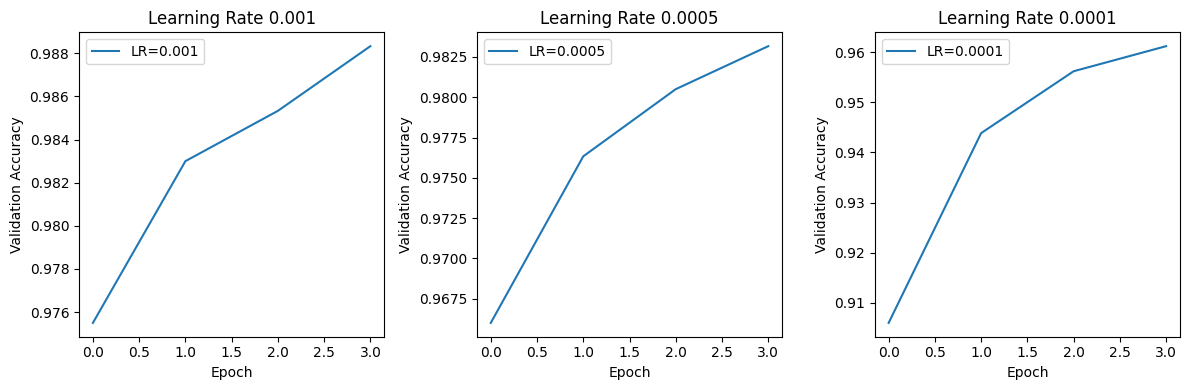

Filters Small [16, 32] -> Val acc: 0.9858
Filters Medium [32, 64] -> Val acc: 0.9877
Filters Large [48, 96] -> Val acc: 0.9887


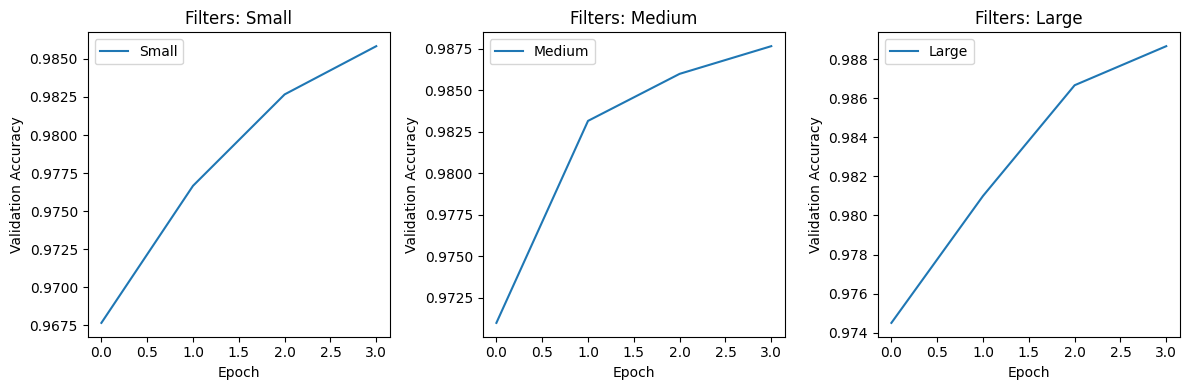

Optimizer Adam -> Val acc: 0.9873
Optimizer SGD -> Val acc: 0.9828


In [ ]:
import subprocess
import sys
import importlib
import gc
import os

# Install packages if missing
def install_if_missing(package):
    try:
        importlib.import_module(package)
        print(f"✓ {package} already installed")
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

install_if_missing("tensorflow")
install_if_missing("matplotlib")
install_if_missing("scikit-learn")

# Optional: Force CPU
# os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.layers import Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import numpy as np

# Clear memory
tf.keras.backend.clear_session()
gc.collect()

# Load MNIST dataset
(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

# Normalize data
train_images = train_images / 255.0
test_images = test_images / 255.0

# Reshape images
train_images = train_images.reshape(-1, 28, 28, 1)
test_images = test_images.reshape(-1, 28, 28, 1)

# Split validation data
train_images, val_images, train_labels, val_labels = train_test_split(
    train_images,
    train_labels,
    test_size=0.1,
    random_state=42
)

print(f"Train: {train_images.shape}")
print(f"Validation: {val_images.shape}")
print(f"Test: {test_images.shape}")

# Build CNN Model
def build_small_cnn(filter_sizes=[32, 64], dropout_rate=0.5):

    model = models.Sequential()

    model.add(
        layers.Conv2D(
            filter_sizes[0],
            (3, 3),
            activation='relu',
            input_shape=(28, 28, 1)
        )
    )

    model.add(layers.MaxPooling2D((2, 2)))

    model.add(
        layers.Conv2D(
            filter_sizes[1],
            (3, 3),
            activation='relu'
        )
    )

    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Flatten())

    model.add(Dropout(dropout_rate))

    model.add(layers.Dense(64, activation='relu'))

    model.add(Dropout(dropout_rate))

    model.add(layers.Dense(10, activation='softmax'))

    return model


# Clear memory function
def clear_memory():
    tf.keras.backend.clear_session()
    gc.collect()


# =====================================================
# LEARNING RATE EXPERIMENT
# =====================================================

learning_rates = [0.001, 0.0005, 0.0001]

val_accs_lr = []

plt.figure(figsize=(12, 4))

for i, lr in enumerate(learning_rates):

    clear_memory()

    model = build_small_cnn()

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        train_images,
        train_labels,
        validation_data=(val_images, val_labels),
        epochs=4,
        batch_size=128,
        verbose=0
    )

    best_val = max(history.history['val_accuracy'])

    val_accs_lr.append(best_val)

    print(f"LR={lr} -> Val accuracy: {best_val:.4f}")

    plt.subplot(1, 3, i + 1)

    plt.plot(history.history['val_accuracy'], label=f'LR={lr}')

    plt.title(f'Learning Rate {lr}')

    plt.xlabel('Epoch')

    plt.ylabel('Validation Accuracy')

    plt.legend()

    del model
    del history

    clear_memory()

plt.tight_layout()
plt.show()


# =====================================================
# FILTER SIZE EXPERIMENT
# =====================================================

filter_configs = {
    'Small': [16, 32],
    'Medium': [32, 64],
    'Large': [48, 96]
}

val_accs_filters = []

plt.figure(figsize=(12, 4))

for i, (name, filters) in enumerate(filter_configs.items()):

    clear_memory()

    model = build_small_cnn(filter_sizes=filters)

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        train_images,
        train_labels,
        validation_data=(val_images, val_labels),
        epochs=4,
        batch_size=128,
        verbose=0
    )

    best_val = max(history.history['val_accuracy'])

    val_accs_filters.append(best_val)

    print(f"Filters {name} {filters} -> Val acc: {best_val:.4f}")

    plt.subplot(1, 3, i + 1)

    plt.plot(history.history['val_accuracy'], label=name)

    plt.title(f'Filters: {name}')

    plt.xlabel('Epoch')

    plt.ylabel('Validation Accuracy')

    plt.legend()

    del model
    del history

    clear_memory()

plt.tight_layout()
plt.show()


# =====================================================
# OPTIMIZER EXPERIMENT
# =====================================================

optimizers_dict = {
    'Adam': Adam(learning_rate=0.001),
    'SGD': SGD(learning_rate=0.01, momentum=0.9),
    'RMSprop': RMSprop(learning_rate=0.001)
}

val_accs_opt = []

plt.figure(figsize=(12, 4))

for i, (opt_name, opt) in enumerate(optimizers_dict.items()):

    clear_memory()

    model = build_small_cnn()

    model.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        train_images,
        train_labels,
        validation_data=(val_images, val_labels),
        epochs=4,
        batch_size=128,
        verbose=0
    )

    best_val = max(history.history['val_accuracy'])

    val_accs_opt.append(best_val)

    print(f"Optimizer {opt_name} -> Val acc: {best_val:.4f}")

    plt.subplot(1, 3, i + 1)

    plt.plot(history.history['val_accuracy'], label=opt_name)

    plt.title(f'Optimizer: {opt_name}')

    plt.xlabel('Epoch')

    plt.ylabel('Validation Accuracy')

    plt.legend()

    del model
    del history

    clear_memory()

plt.tight_layout()
plt.show()


# =====================================================
# DROPOUT EXPERIMENT
# =====================================================

dropout_rates = [0.3, 0.5, 0.7]

val_accs_drop = []

plt.figure(figsize=(12, 4))

for i, dr in enumerate(dropout_rates):

    clear_memory()

    model = build_small_cnn(dropout_rate=dr)

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        train_images,
        train_labels,
        validation_data=(val_images, val_labels),
        epochs=4,
        batch_size=128,
        verbose=0
    )

    best_val = max(history.history['val_accuracy'])

    val_accs_drop.append(best_val)

    print(f"Dropout {dr} -> Val acc: {best_val:.4f}")

    plt.subplot(1, 3, i + 1)

    plt.plot(history.history['val_accuracy'], label=f'Dropout={dr}')

    plt.title(f'Dropout Rate {dr}')

    plt.xlabel('Epoch')

    plt.ylabel('Validation Accuracy')

    plt.legend()

    del model
    del history

    clear_memory()

plt.tight_layout()
plt.show()


# =====================================================
# FINAL MODEL
# =====================================================

clear_memory()

# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(train_images)

final_model = build_small_cnn(
    filter_sizes=[32, 64],
    dropout_rate=0.5
)

final_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_final = final_model.fit(
    datagen.flow(train_images, train_labels, batch_size=64),
    epochs=10,
    validation_data=(val_images, val_labels),
    verbose=1
)

# Evaluate
test_loss, test_acc = final_model.evaluate(
    test_images,
    test_labels,
    verbose=0
)

print(f"\nTest Accuracy: {test_acc:.4f}")


# =====================================================
# FINAL PLOTS
# =====================================================

plt.figure(figsize=(12, 4))

# Accuracy Plot
plt.subplot(1, 2, 1)

plt.plot(history_final.history['accuracy'], label='Train Accuracy')

plt.plot(history_final.history['val_accuracy'], label='Validation Accuracy')

plt.title('Accuracy over Epochs')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend()

plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)

plt.plot(history_final.history['loss'], label='Train Loss')

plt.plot(history_final.history['val_loss'], label='Validation Loss')

plt.title('Loss over Epochs')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()